In [1]:
!pip install kagglehub xgboost transformers sentence-transformers \
             torch torchvision torchaudio \
             nltk gensim shap lime -q

import kagglehub, os, warnings, re, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from collections import Counter
warnings.filterwarnings('ignore')

# NLP
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

# ML
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# DL
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, LSTM, GRU,
                                     Embedding, GlobalMaxPooling1D,
                                     Bidirectional, Input, BatchNormalization)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Word2Vec / GloVe
import gensim
from gensim.models import Word2Vec

# Transformers
import torch
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          BertTokenizer, BertForSequenceClassification,
                          RobertaTokenizer, RobertaForSequenceClassification,
                          Trainer, TrainingArguments)
from sentence_transformers import SentenceTransformer
from torch.utils.data import Dataset, DataLoader

# WordCloud
try:
    from wordcloud import WordCloud
    WC_AVAILABLE = True
except:
    WC_AVAILABLE = False
    print("WordCloud not available, skipping wordcloud plots")

print("✅ All libraries imported!")
print(f"TensorFlow : {tf.__version__}")
print(f"PyTorch    : {torch.__version__}")

✅ All libraries imported!
TensorFlow : 2.20.0
PyTorch    : 2.10.0+cu128


In [2]:
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")
print("📁 Dataset path:", path)

for root, dirs, files in os.walk(path):
    for f in files:
        print(os.path.join(root, f))

📁 Dataset path: /kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset
/kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset/True.csv
/kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset/Fake.csv


In [3]:
fake_path = os.path.join(path, "Fake.csv")
real_path = os.path.join(path, "True.csv")

fake_df = pd.read_csv(fake_path)
real_df = pd.read_csv(real_path)

# Add labels
fake_df['label'] = 1   # 1 = Fake
real_df['label'] = 0   # 0 = Real

print("Fake news shape:", fake_df.shape)
print("Real news shape:", real_df.shape)

fake_df.head(3)

Fake news shape: (23481, 5)
Real news shape: (21417, 5)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1


In [4]:
df = pd.concat([fake_df, real_df], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print("Combined shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nLabel distribution:")
print(df['label'].value_counts())
print(f"\nFake: {(df['label']==1).sum()}  |  Real: {(df['label']==0).sum()}")

df.head(3)

Combined shape: (44898, 5)

Columns: ['title', 'text', 'subject', 'date', 'label']

Label distribution:
label
1    23481
0    21417
Name: count, dtype: int64

Fake: 23481  |  Real: 21417


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0


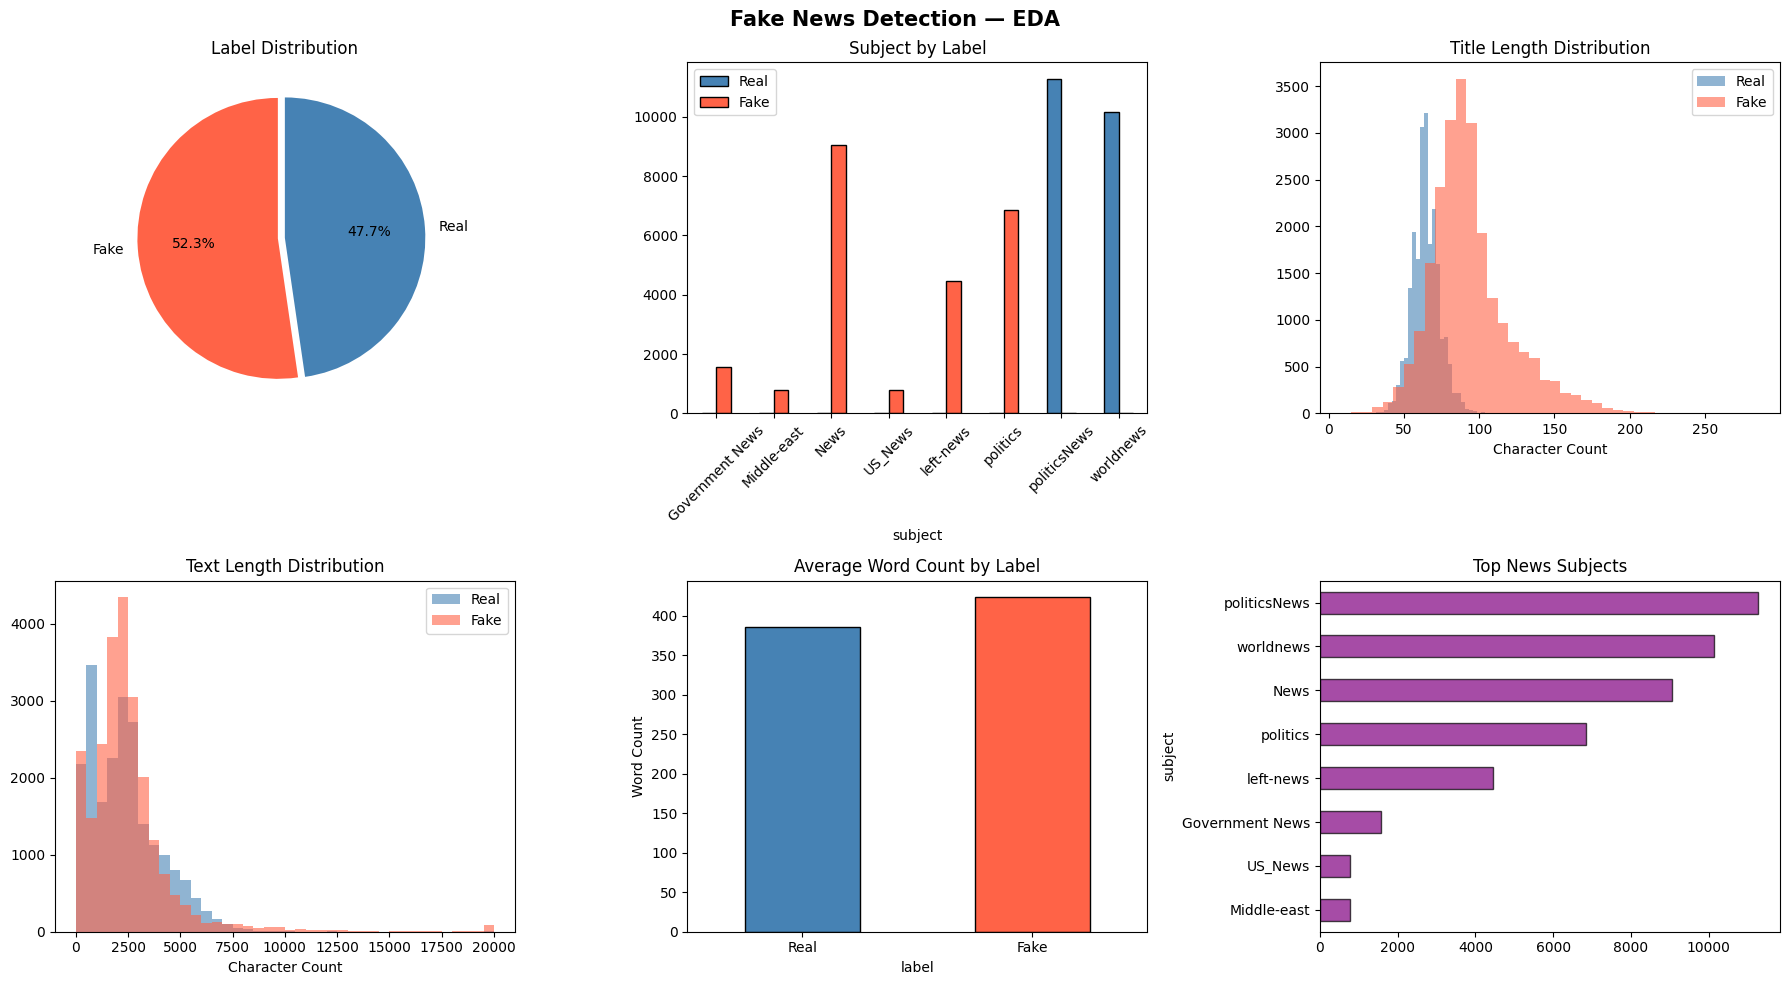

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Fake News Detection — EDA', fontsize=15, fontweight='bold')

# 5a. Label distribution
axes[0,0].pie([fake_df.shape[0], real_df.shape[0]],
              labels=['Fake', 'Real'],
              autopct='%1.1f%%',
              colors=['tomato', 'steelblue'],
              startangle=90, explode=(0.05, 0))
axes[0,0].set_title('Label Distribution')

# 5b. Subject distribution
if 'subject' in df.columns:
    subj = df.groupby(['subject','label']).size().unstack(fill_value=0)
    subj.plot(kind='bar', ax=axes[0,1], color=['steelblue','tomato'],
              edgecolor='black')
    axes[0,1].set_title('Subject by Label')
    axes[0,1].tick_params(axis='x', rotation=45)
    axes[0,1].legend(['Real','Fake'])
else:
    axes[0,1].text(0.5, 0.5, 'No Subject Column', ha='center', va='center')

# 5c. Text length distribution (title)
df['title_len'] = df['title'].fillna('').apply(len)
axes[0,2].hist(df[df['label']==0]['title_len'], bins=40,
               alpha=0.6, color='steelblue', label='Real')
axes[0,2].hist(df[df['label']==1]['title_len'], bins=40,
               alpha=0.6, color='tomato', label='Fake')
axes[0,2].set_title('Title Length Distribution')
axes[0,2].set_xlabel('Character Count')
axes[0,2].legend()

# 5d. Text length distribution (text body)
df['text_len'] = df['text'].fillna('').apply(len)
axes[1,0].hist(df[df['label']==0]['text_len'].clip(upper=20000), bins=40,
               alpha=0.6, color='steelblue', label='Real')
axes[1,0].hist(df[df['label']==1]['text_len'].clip(upper=20000), bins=40,
               alpha=0.6, color='tomato', label='Fake')
axes[1,0].set_title('Text Length Distribution')
axes[1,0].set_xlabel('Character Count')
axes[1,0].legend()

# 5e. Word count
df['word_count'] = df['text'].fillna('').apply(lambda x: len(x.split()))
df.groupby('label')['word_count'].mean().plot(kind='bar', ax=axes[1,1],
    color=['steelblue','tomato'], edgecolor='black')
axes[1,1].set_title('Average Word Count by Label')
axes[1,1].set_xticklabels(['Real','Fake'], rotation=0)
axes[1,1].set_ylabel('Word Count')

# 5f. Top subjects (if available)
if 'subject' in df.columns:
    df['subject'].value_counts().head(8).plot(kind='barh', ax=axes[1,2],
        color='purple', edgecolor='black', alpha=0.7)
    axes[1,2].set_title('Top News Subjects')
    axes[1,2].invert_yaxis()
else:
    axes[1,2].text(0.5, 0.5, 'No Subject Column', ha='center', va='center')

plt.tight_layout()
plt.show()

In [6]:
STOP_WORDS = set(stopwords.words('english'))
stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def clean_text(text, use_stem=False, use_lemma=True):
    """Full NLP text cleaning pipeline."""
    if not isinstance(text, str):
        return ""

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove special characters & digits
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Stopword Removal
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]

    # Stemming OR Lemmatization
    if use_stem:
        tokens = [stemmer.stem(t) for t in tokens]
    elif use_lemma:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)

# Combine title + text for better features
df['content'] = df['title'].fillna('') + ' ' + df['text'].fillna('')

# Apply cleaning (use sample for speed if needed)
print("Cleaning text... (this may take a minute)")
df['cleaned']       = df['content'].apply(lambda x: clean_text(x, use_lemma=True))
df['cleaned_stem']  = df['content'].apply(lambda x: clean_text(x, use_stem=True))

print(" Text cleaning done!")
print("\nSample cleaned text:")
print(df['cleaned'].iloc[0][:300])

Cleaning text... (this may take a minute)
✅ Text cleaning done!

Sample cleaned text:
ben stein call circuit court committed coup dtat constitution century wire say ben stein reputable professor pepperdine university also hollywood fame appearing show film ferris bueller day made provocative statement judge jeanine pirro show recently discussing halt imposed president trump executive


In [7]:
sample = df['content'].iloc[0][:500]
print(" TOKENIZATION DEMO")
print("="*55)
print("Original Text (first 500 chars):")
print(sample)

print("\n Word Tokenization:")
tokens = word_tokenize(sample.lower())
print(tokens[:20])

print("\n After Stopword Removal:")
no_stop = [t for t in tokens if t not in STOP_WORDS and t.isalpha()]
print(no_stop[:20])

print("\n After Stemming:")
stemmed = [stemmer.stem(t) for t in no_stop]
print(stemmed[:20])

print("\n After Lemmatization:")
lemmatized = [lemmatizer.lemmatize(t) for t in no_stop]
print(lemmatized[:20])

 TOKENIZATION DEMO
Original Text (first 500 chars):
Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washingto

 Word Tokenization:
['ben', 'stein', 'calls', 'out', '9th', 'circuit', 'court', ':', 'committed', 'a', '‘', 'coup', 'd', '’', 'état', '’', 'against', 'the', 'constitution', '21st']

 After Stopword Removal:
['ben', 'stein', 'calls', 'circuit', 'court', 'committed', 'coup', 'état', 'constitution', 'century', 'wire', 'says', 'ben', 'stein', 'reputable', 'professor', 'pepperdine', 'university', 'also', 'hollywood']

 After Stemming:
['ben', 'ste

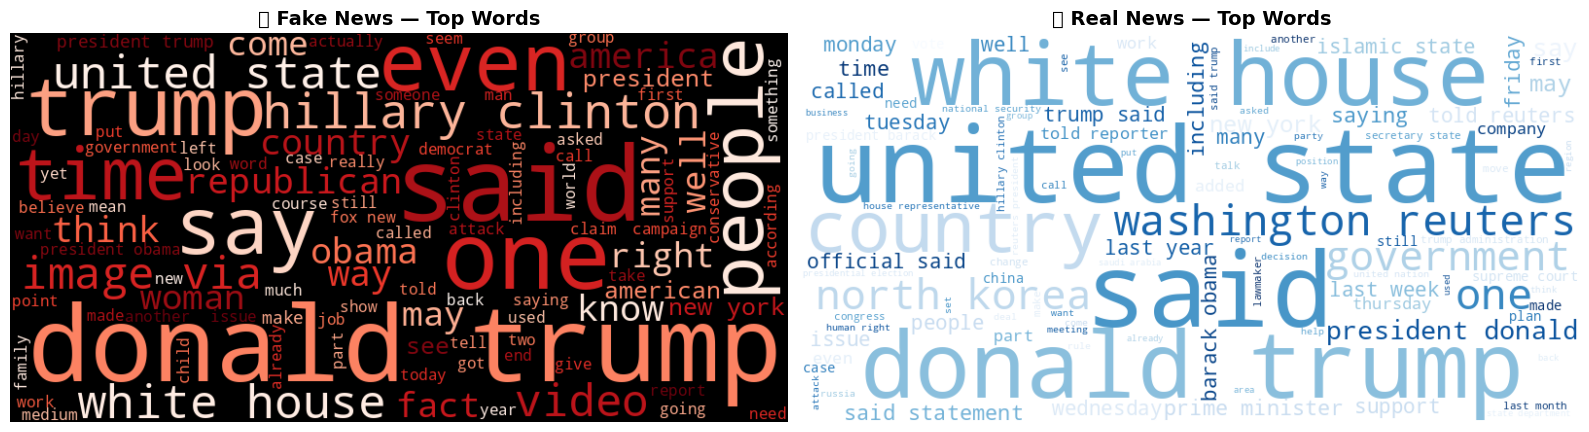

In [8]:
if WC_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    fake_text = ' '.join(df[df['label']==1]['cleaned'].tolist())
    real_text = ' '.join(df[df['label']==0]['cleaned'].tolist())

    wc_fake = WordCloud(width=800, height=400,
                        background_color='black',
                        colormap='Reds',
                        max_words=100).generate(fake_text)

    wc_real = WordCloud(width=800, height=400,
                        background_color='white',
                        colormap='Blues',
                        max_words=100).generate(real_text)

    axes[0].imshow(wc_fake, interpolation='bilinear')
    axes[0].axis('off')
    axes[0].set_title('🔴 Fake News — Top Words', fontsize=14, fontweight='bold')

    axes[1].imshow(wc_real, interpolation='bilinear')
    axes[1].axis('off')
    axes[1].set_title('🔵 Real News — Top Words', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    # Top words bar chart as alternative
    def top_words(texts, n=20):
        all_words = ' '.join(texts).split()
        return Counter(all_words).most_common(n)

    fake_words = top_words(df[df['label']==1]['cleaned'])
    real_words = top_words(df[df['label']==0]['cleaned'])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].barh([w[0] for w in fake_words], [w[1] for w in fake_words],
                 color='tomato')
    axes[0].set_title('Top Words — Fake News')
    axes[0].invert_yaxis()

    axes[1].barh([w[0] for w in real_words], [w[1] for w in real_words],
                 color='steelblue')
    axes[1].set_title('Top Words — Real News')
    axes[1].invert_yaxis()
    plt.tight_layout(); plt.show()

In [9]:
SAMPLE_SIZE = 20000   # full dataset use করতে চাইলে None দাও

if SAMPLE_SIZE and len(df) > SAMPLE_SIZE:
    df_sample = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
    print(f"Using {SAMPLE_SIZE} samples for speed")
else:
    df_sample = df.copy()
    print(f"Using full dataset: {len(df)} samples")

X_text = df_sample['cleaned'].values
y      = df_sample['label'].values

X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y)

X_train_txt, X_val_txt, y_train, y_val = train_test_split(
    X_train_txt, y_train, test_size=0.1, random_state=42, stratify=y_train)

print(f"Train: {len(X_train_txt)}  |  Val: {len(X_val_txt)}  |  Test: {len(X_test_txt)}")
print(f"Label distribution — Train: {pd.Series(y_train).value_counts().to_dict()}")

Using 20000 samples for speed
Train: 14400  |  Val: 1600  |  Test: 4000
Label distribution — Train: {1: 7524, 0: 6876}


In [10]:
tfidf = TfidfVectorizer(
    max_features = 50000,
    ngram_range  = (1, 2),    # unigram + bigram
    min_df       = 2,
    sublinear_tf = True
)

X_train_tfidf = tfidf.fit_transform(X_train_txt)
X_val_tfidf   = tfidf.transform(X_val_txt)
X_test_tfidf  = tfidf.transform(X_test_txt)

print(f"TF-IDF Matrix shape: {X_train_tfidf.shape}")

# Top TF-IDF terms
feature_names_tfidf = tfidf.get_feature_names_out()
print("\nSample TF-IDF features:", feature_names_tfidf[:20])

TF-IDF Matrix shape: (14400, 50000)

Sample TF-IDF features: ['aaplo' 'aaron' 'aba' 'aba aslani' 'ababa' 'aback' 'abadi' 'abandon'
 'abandoned' 'abandoning' 'abasaslani' 'abasaslani january' 'abbas'
 'abbas said' 'abbasi' 'abbott' 'abby' 'abc' 'abc cbs' 'abc good']


In [11]:
bow = CountVectorizer(
    max_features = 30000,
    ngram_range  = (1, 2),
    min_df       = 2
)

X_train_bow = bow.fit_transform(X_train_txt)
X_test_bow  = bow.transform(X_test_txt)

print(f"BoW Matrix shape: {X_train_bow.shape}")

BoW Matrix shape: (14400, 30000)


In [12]:
results = {}

def evaluate(name, y_true, y_pred, y_prob=None, feature_type=''):
    acc = accuracy_score(y_true, y_pred)

    if y_prob is not None:
        auc = roc_auc_score(y_true, y_prob)
    else:
        auc = roc_auc_score(y_true, y_pred)

    label = f"{name} ({feature_type})" if feature_type else name
    results[label] = {'Accuracy': acc, 'ROC-AUC': auc}

    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(classification_report(y_true, y_pred,
          target_names=['Real', 'Fake']))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Real','Fake'],
                yticklabels=['Real','Fake'])
    plt.title(f'{name} — Confusion Matrix')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout(); plt.show()

    return auc


  Logistic Regression (TF-IDF)
  Accuracy : 0.9892
  ROC-AUC  : 0.9991
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      1910
        Fake       0.99      0.99      0.99      2090

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000



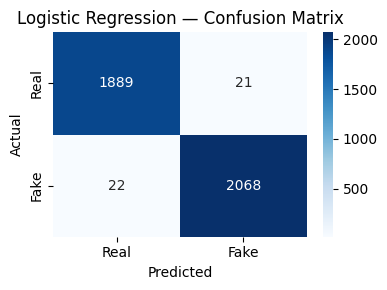


  Logistic Regression (BoW)
  Accuracy : 0.9962
  ROC-AUC  : 0.9989
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      1910
        Fake       1.00      1.00      1.00      2090

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



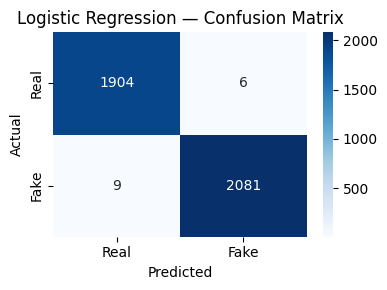

np.float64(0.9988794809489216)

In [13]:
# TF-IDF
lr_tfidf = LogisticRegression(max_iter=1000, C=1.0,
                               solver='lbfgs', random_state=42)
lr_tfidf.fit(X_train_tfidf, y_train)
lr_pred  = lr_tfidf.predict(X_test_tfidf)
lr_prob  = lr_tfidf.predict_proba(X_test_tfidf)[:, 1]
evaluate('Logistic Regression', y_test, lr_pred, lr_prob, 'TF-IDF')

# BoW
lr_bow  = LogisticRegression(max_iter=1000, random_state=42)
lr_bow.fit(X_train_bow, y_train)
lr_pred2= lr_bow.predict(X_test_bow)
lr_prob2= lr_bow.predict_proba(X_test_bow)[:, 1]
evaluate('Logistic Regression', y_test, lr_pred2, lr_prob2, 'BoW')


  Naive Bayes (TF-IDF)
  Accuracy : 0.9680
  ROC-AUC  : 0.9938
              precision    recall  f1-score   support

        Real       0.97      0.96      0.97      1910
        Fake       0.97      0.97      0.97      2090

    accuracy                           0.97      4000
   macro avg       0.97      0.97      0.97      4000
weighted avg       0.97      0.97      0.97      4000



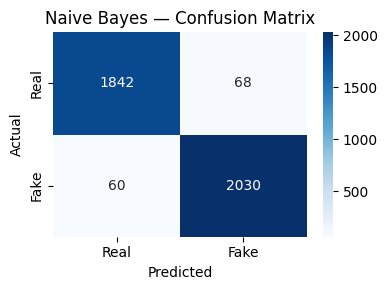


  Naive Bayes (BoW)
  Accuracy : 0.9700
  ROC-AUC  : 0.9858
              precision    recall  f1-score   support

        Real       0.97      0.97      0.97      1910
        Fake       0.97      0.97      0.97      2090

    accuracy                           0.97      4000
   macro avg       0.97      0.97      0.97      4000
weighted avg       0.97      0.97      0.97      4000



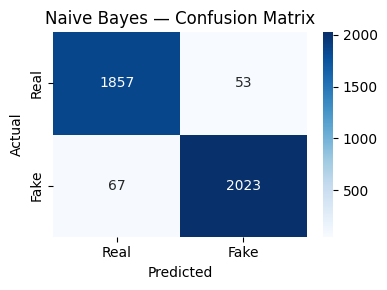

np.float64(0.9858403266614896)

In [14]:
# TF-IDF (needs non-negative values — TF-IDF is fine)
nb_tfidf = MultinomialNB(alpha=0.1)
nb_tfidf.fit(abs(X_train_tfidf), y_train)
nb_pred  = nb_tfidf.predict(abs(X_test_tfidf))
nb_prob  = nb_tfidf.predict_proba(abs(X_test_tfidf))[:, 1]
evaluate('Naive Bayes', y_test, nb_pred, nb_prob, 'TF-IDF')

# BoW
nb_bow  = MultinomialNB(alpha=0.1)
nb_bow.fit(X_train_bow, y_train)
nb_pred2= nb_bow.predict(X_test_bow)
nb_prob2= nb_bow.predict_proba(X_test_bow)[:, 1]
evaluate('Naive Bayes', y_test, nb_pred2, nb_prob2, 'BoW')


  SVM (LinearSVC) (TF-IDF)
  Accuracy : 0.9968
  ROC-AUC  : 0.9996
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      1910
        Fake       1.00      1.00      1.00      2090

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



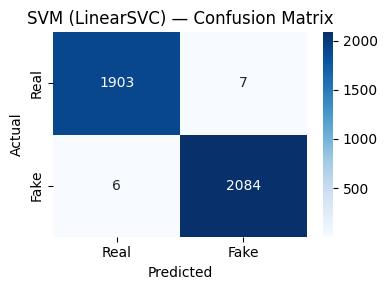

np.float64(0.9995984368345899)

In [15]:
svm_tfidf = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_tfidf.fit(X_train_tfidf, y_train)
svm_pred  = svm_tfidf.predict(X_test_tfidf)

# LinearSVC has no predict_proba → use decision function
svm_score = svm_tfidf.decision_function(X_test_tfidf)
evaluate('SVM (LinearSVC)', y_test, svm_pred, svm_score, 'TF-IDF')


  Random Forest (TF-IDF)
  Accuracy : 0.9932
  ROC-AUC  : 0.9997
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      1910
        Fake       0.99      0.99      0.99      2090

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000



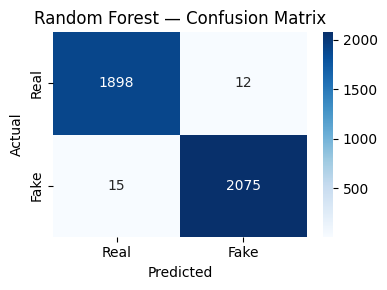

np.float64(0.9996511686164482)

In [16]:
rf_tfidf = RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                   random_state=42)
rf_tfidf.fit(X_train_tfidf, y_train)
rf_pred  = rf_tfidf.predict(X_test_tfidf)
rf_prob  = rf_tfidf.predict_proba(X_test_tfidf)[:, 1]
evaluate('Random Forest', y_test, rf_pred, rf_prob, 'TF-IDF')


  XGBoost (TF-IDF)
  Accuracy : 0.9968
  ROC-AUC  : 0.9993
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      1910
        Fake       1.00      1.00      1.00      2090

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



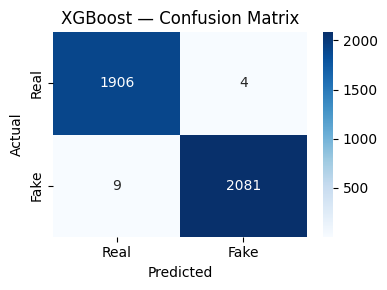

np.float64(0.9993146120894811)

In [17]:
xgb = XGBClassifier(n_estimators=200, learning_rate=0.1,
                    max_depth=5, use_label_encoder=False,
                    eval_metric='logloss', tree_method='hist',
                    random_state=42, n_jobs=-1)
xgb.fit(X_train_tfidf, y_train)
xgb_pred = xgb.predict(X_test_tfidf)
xgb_prob = xgb.predict_proba(X_test_tfidf)[:, 1]
evaluate('XGBoost', y_test, xgb_pred, xgb_prob, 'TF-IDF')

✅ Word2Vec trained! Vocab size: 51311

Words similar to 'election':
[('electionthe', 0.6265106201171875), ('electoral', 0.6190290451049805), ('usinfonewscom', 0.6158995628356934), ('electionif', 0.5328959822654724), ('electiontrump', 0.5226858854293823)]
Word2Vec feature shape: (14400, 100)

  Logistic Regression (Word2Vec)
  Accuracy : 0.9735
  ROC-AUC  : 0.9961
              precision    recall  f1-score   support

        Real       0.97      0.97      0.97      1910
        Fake       0.98      0.97      0.97      2090

    accuracy                           0.97      4000
   macro avg       0.97      0.97      0.97      4000
weighted avg       0.97      0.97      0.97      4000



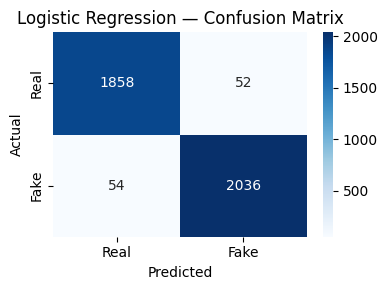

np.float64(0.9961291615521431)

In [18]:
# Tokenize for Word2Vec
train_tokens = [text.split() for text in X_train_txt]

w2v_model = Word2Vec(
    sentences  = train_tokens,
    vector_size= 100,
    window     = 5,
    min_count  = 2,
    workers    = 4,
    epochs     = 10
)

print(f"✅ Word2Vec trained! Vocab size: {len(w2v_model.wv)}")

# Similar words demo
print("\nWords similar to 'election':")
try:
    print(w2v_model.wv.most_similar('election', topn=5))
except:
    print("'election' not in vocab")

def get_w2v_vector(text, model, size=100):
    """Average Word2Vec vectors for a document."""
    words = text.split()
    vecs  = [model.wv[w] for w in words if w in model.wv]
    if vecs:
        return np.mean(vecs, axis=0)
    return np.zeros(size)

X_train_w2v = np.array([get_w2v_vector(t, w2v_model) for t in X_train_txt])
X_test_w2v  = np.array([get_w2v_vector(t, w2v_model) for t in X_test_txt])

print(f"Word2Vec feature shape: {X_train_w2v.shape}")

# Logistic Regression on Word2Vec
lr_w2v = LogisticRegression(max_iter=1000, random_state=42)
lr_w2v.fit(X_train_w2v, y_train)
w2v_pred = lr_w2v.predict(X_test_w2v)
w2v_prob = lr_w2v.predict_proba(X_test_w2v)[:, 1]
evaluate('Logistic Regression', y_test, w2v_pred, w2v_prob, 'Word2Vec')

✅ GloVe downloaded!
✅ GloVe loaded! Vocab: 400000
GloVe feature shape: (14400, 100)

  Logistic Regression (GloVe)
  Accuracy : 0.9395
  ROC-AUC  : 0.9858
              precision    recall  f1-score   support

        Real       0.94      0.94      0.94      1910
        Fake       0.94      0.94      0.94      2090

    accuracy                           0.94      4000
   macro avg       0.94      0.94      0.94      4000
weighted avg       0.94      0.94      0.94      4000



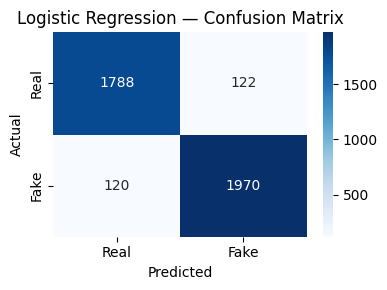

np.float64(0.9858453368070343)

In [19]:
# Download GloVe (small version)
GLOVE_PATH = 'glove.6B.100d.txt'
if not os.path.exists(GLOVE_PATH):
    import urllib.request, zipfile
    print("Downloading GloVe 6B 100d...")
    url = "http://nlp.stanford.edu/data/glove.6B.zip"
    try:
        urllib.request.urlretrieve(url, "glove.6B.zip")
        with zipfile.ZipFile("glove.6B.zip", 'r') as z:
            z.extract("glove.6B.100d.txt", ".")
        print("✅ GloVe downloaded!")
    except Exception as e:
        print(f"⚠️ GloVe download failed: {e}")
        print("Generating random GloVe-like vectors as fallback...")
        GLOVE_PATH = None

# Load GloVe vectors
glove_vectors = {}
if GLOVE_PATH and os.path.exists(GLOVE_PATH):
    with open(GLOVE_PATH, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.split()
            word  = parts[0]
            vec   = np.array(parts[1:], dtype=np.float32)
            glove_vectors[word] = vec
    print(f"✅ GloVe loaded! Vocab: {len(glove_vectors)}")
else:
    print("Using Word2Vec as GloVe substitute for this run.")
    glove_vectors = {word: w2v_model.wv[word]
                     for word in w2v_model.wv.key_to_index}

def get_glove_vector(text, glove_dict, size=100):
    words = text.split()
    vecs  = [glove_dict[w] for w in words if w in glove_dict]
    if vecs:
        return np.mean(vecs, axis=0)
    return np.zeros(size)

X_train_glove = np.array([get_glove_vector(t, glove_vectors) for t in X_train_txt])
X_test_glove  = np.array([get_glove_vector(t, glove_vectors) for t in X_test_txt])

print(f"GloVe feature shape: {X_train_glove.shape}")

# Logistic Regression on GloVe
lr_glove = LogisticRegression(max_iter=1000, random_state=42)
lr_glove.fit(X_train_glove, y_train)
glv_pred = lr_glove.predict(X_test_glove)
glv_prob = lr_glove.predict_proba(X_test_glove)[:, 1]
evaluate('Logistic Regression', y_test, glv_pred, glv_prob, 'GloVe')

In [20]:
MAX_VOCAB  = 50000
MAX_LEN    = 300

keras_tok = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
keras_tok.fit_on_texts(X_train_txt)

def encode_texts(texts):
    seqs = keras_tok.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN,
                         padding='post', truncating='post')

X_train_pad = encode_texts(X_train_txt)
X_val_pad   = encode_texts(X_val_txt)
X_test_pad  = encode_texts(X_test_txt)

print(f"Padded shape — Train: {X_train_pad.shape}  Test: {X_test_pad.shape}")

# Build GloVe Embedding Matrix for DL models
EMB_DIM = 100
word_index = keras_tok.word_index
vocab_size  = min(MAX_VOCAB, len(word_index)) + 1

embedding_matrix = np.zeros((vocab_size, EMB_DIM))
for word, idx in word_index.items():
    if idx >= MAX_VOCAB:
        continue
    vec = glove_vectors.get(word)
    if vec is not None:
        embedding_matrix[idx] = vec

print(f"Embedding matrix shape: {embedding_matrix.shape}")

Padded shape — Train: (14400, 300)  Test: (4000, 300)
Embedding matrix shape: (50001, 100)


I0000 00:00:1783263073.120390      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783263073.126665      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     5,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,000,100 (19.07 MB)

 Trainable params: 5,000,100 (19.07 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 18s 93ms/step - accuracy: 0.9443 - loss: 0.1419 - val_accuracy: 0.9975 - val_loss: 0.0158 - learning_rate: 0.0010
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 0.9969 - loss: 0.0120 - val_accuracy: 0.9975 - val_loss: 0.0170 - learning_rate: 0.0010
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - accuracy: 0.9980 - loss: 0.0073 - val_accuracy: 0.9975 - val_loss: 0.0212 - learning_rate: 0.0010
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - accuracy: 0.9986 - loss: 0.0069 - val_accuracy: 0.9975 - val_loss: 0.0183 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


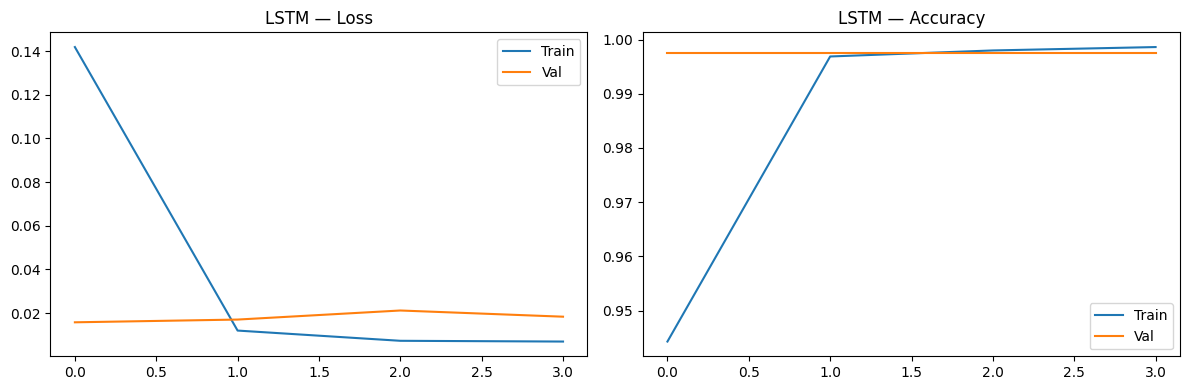

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step

  BiLSTM (GloVe Emb)
  Accuracy : 0.9988
  ROC-AUC  : 1.0000
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      1910
        Fake       1.00      1.00      1.00      2090

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



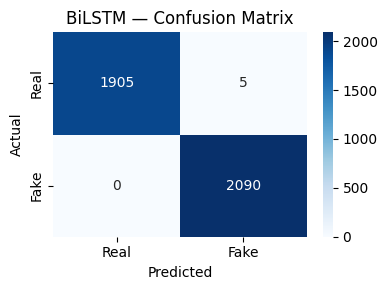

np.float64(0.9999867231143065)

In [21]:
def build_lstm(vocab_size, emb_dim, max_len, emb_matrix):
    model = Sequential([
        Embedding(vocab_size, emb_dim,
                  weights=[emb_matrix],
                  input_length=max_len,
                  trainable=True),
        Bidirectional(LSTM(128, return_sequences=True, dropout=0.3)),
        Bidirectional(LSTM(64,  dropout=0.3)),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(1,  activation='sigmoid')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

lstm_model = build_lstm(vocab_size, EMB_DIM, MAX_LEN, embedding_matrix)
lstm_model.summary()

es  = EarlyStopping(patience=3, restore_best_weights=True, verbose=1)
rlr = ReduceLROnPlateau(patience=2, factor=0.5, verbose=0)

h_lstm = lstm_model.fit(
    X_train_pad, y_train,
    validation_data = (X_val_pad, y_val),
    epochs=10, batch_size=128,
    callbacks=[es, rlr], verbose=1
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h_lstm.history['loss'],     label='Train')
axes[0].plot(h_lstm.history['val_loss'], label='Val')
axes[0].set_title('LSTM — Loss'); axes[0].legend()
axes[1].plot(h_lstm.history['accuracy'],     label='Train')
axes[1].plot(h_lstm.history['val_accuracy'], label='Val')
axes[1].set_title('LSTM — Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

lstm_prob = lstm_model.predict(X_test_pad, batch_size=256).ravel()
lstm_pred = (lstm_prob > 0.5).astype(int)
evaluate('BiLSTM', y_test, lstm_pred, lstm_prob, 'GloVe Emb')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     5,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,000,100 (19.07 MB)

 Trainable params: 5,000,100 (19.07 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - accuracy: 0.9411 - loss: 0.1385 - val_accuracy: 0.9975 - val_loss: 0.0194 - learning_rate: 0.0010
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - accuracy: 0.9975 - loss: 0.0144 - val_accuracy: 0.9975 - val_loss: 0.0186 - learning_rate: 0.0010
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.9986 - loss: 0.0102 - val_accuracy: 0.9975 - val_loss: 0.0166 - learning_rate: 0.0010
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.9984 - loss: 0.0090 - val_accuracy: 0.9975 - val_loss: 0.0182 - learning_rate: 0.0010
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.9987 - loss: 0.0061 - val_accuracy: 0.9975 - val_loss: 0.0193 - learning_rate: 0.0010
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.9990 - loss: 0.0043 - val_accuracy: 0.9975 - val_loss: 0.0224 - learning_rate: 5.0000e-04
Epoch 6: early stopping
Restoring model weights from the end of the best epoc

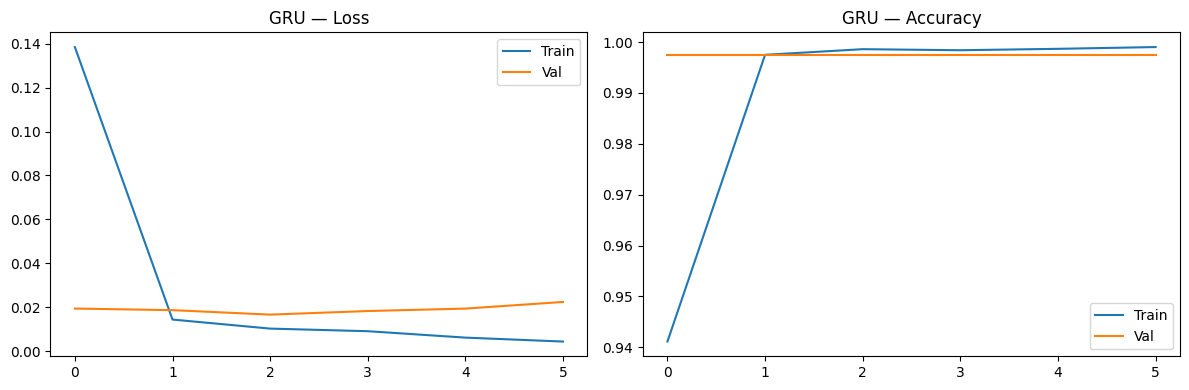

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step

  BiGRU (GloVe Emb)
  Accuracy : 0.9988
  ROC-AUC  : 0.9999
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      1910
        Fake       1.00      1.00      1.00      2090

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



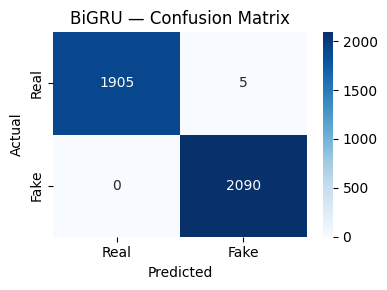

np.float64(0.9999123224529672)

In [22]:
def build_gru(vocab_size, emb_dim, max_len, emb_matrix):
    model = Sequential([
        Embedding(vocab_size, emb_dim,
                  weights=[emb_matrix],
                  input_length=max_len,
                  trainable=True),
        Bidirectional(GRU(128, return_sequences=True, dropout=0.3)),
        Bidirectional(GRU(64,  dropout=0.3)),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(1,  activation='sigmoid')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

gru_model = build_gru(vocab_size, EMB_DIM, MAX_LEN, embedding_matrix)
gru_model.summary()

es2  = EarlyStopping(patience=3, restore_best_weights=True, verbose=1)
rlr2 = ReduceLROnPlateau(patience=2, factor=0.5, verbose=0)

h_gru = gru_model.fit(
    X_train_pad, y_train,
    validation_data = (X_val_pad, y_val),
    epochs=10, batch_size=128,
    callbacks=[es2, rlr2], verbose=1
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h_gru.history['loss'],     label='Train')
axes[0].plot(h_gru.history['val_loss'], label='Val')
axes[0].set_title('GRU — Loss'); axes[0].legend()
axes[1].plot(h_gru.history['accuracy'],     label='Train')
axes[1].plot(h_gru.history['val_accuracy'], label='Val')
axes[1].set_title('GRU — Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

gru_prob = gru_model.predict(X_test_pad, batch_size=256).ravel()
gru_pred = (gru_prob > 0.5).astype(int)
evaluate('BiGRU', y_test, gru_pred, gru_prob, 'GloVe Emb')

In [25]:
!pip install -q --upgrade transformers accelerate

import transformers
print(f"Transformers version: {transformers.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 88.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 28.2 MB/s eta 0:00:00
Transformers version: 5.0.0


In [27]:
print("🤗 BERT Fine-tuning...")

BERT_MODEL  = 'bert-base-uncased'
BERT_MAX    = 128
BERT_BATCH  = 16
BERT_EPOCHS = 2
BERT_TRAIN  = 3000
BERT_TEST   = 800

idx_tr = np.random.choice(len(X_train_txt), BERT_TRAIN, replace=False)
idx_te = np.random.choice(len(X_test_txt),  BERT_TEST,  replace=False)

bert_train_texts  = X_train_txt[idx_tr].tolist()
bert_train_labels = y_train[idx_tr].tolist()
bert_test_texts   = X_test_txt[idx_te].tolist()
bert_test_labels  = y_test[idx_te].tolist()

# Tokenizer
bert_tokenizer = BertTokenizer.from_pretrained(BERT_MODEL)

# Dataset Class
class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length     = self.max_len,
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels'        : torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_ds = NewsDataset(bert_train_texts, bert_train_labels,
                       bert_tokenizer, BERT_MAX)
test_ds  = NewsDataset(bert_test_texts,  bert_test_labels,
                       bert_tokenizer, BERT_MAX)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Model
bert_model = BertForSequenceClassification.from_pretrained(
    BERT_MODEL,
    num_labels             = 2,
    ignore_mismatched_sizes= True
)
bert_model = bert_model.to(device)

# ✅ TrainingArguments — eval_strategy only (no evaluation_strategy)
bert_args = TrainingArguments(
    output_dir                  = './bert_output',
    num_train_epochs            = BERT_EPOCHS,
    per_device_train_batch_size = BERT_BATCH,
    per_device_eval_batch_size  = BERT_BATCH,
    eval_strategy               = 'epoch',
    save_strategy               = 'no',
    logging_steps               = 50,
    load_best_model_at_end      = False,
    report_to                   = 'none',
    fp16                        = torch.cuda.is_available(),
)

# Trainer
trainer = Trainer(
    model         = bert_model,
    args          = bert_args,
    train_dataset = train_ds,
    eval_dataset  = test_ds,
)

print("🚀 Starting BERT Training...")
trainer.train()

🤗 BERT Fine-tuning...
Device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🚀 Starting BERT Training...


Epoch,Training Loss,Validation Loss
1,0.296467,0.010300
2,0.017789,0.013458


TrainOutput(global_step=188, training_loss=0.08863089760725802, metrics={'train_runtime': 108.1378, 'train_samples_per_second': 55.485, 'train_steps_per_second': 1.739, 'total_flos': 394666583040000.0, 'train_loss': 0.08863089760725802, 'epoch': 2.0})


  BERT (Fine-tuned)
  Accuracy : 0.9988
  ROC-AUC  : 1.0000
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00       387
        Fake       1.00      1.00      1.00       413

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800



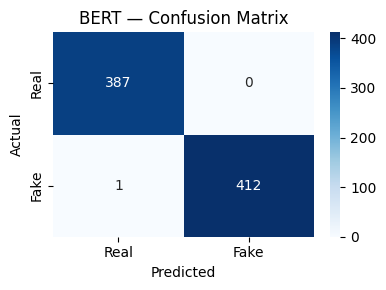

np.float64(1.0)

In [28]:
import torch.nn.functional as F

bert_preds_raw = trainer.predict(test_ds)
bert_logits    = bert_preds_raw.predictions
bert_prob      = F.softmax(torch.tensor(bert_logits), dim=1).numpy()[:, 1]
bert_pred      = np.argmax(bert_logits, axis=1)
bert_true      = np.array(bert_test_labels)

evaluate('BERT', bert_true, bert_pred, bert_prob, 'Fine-tuned')

In [39]:
ROB_MODEL  = 'roberta-base'
ROB_TRAIN  = 3000
ROB_TEST   = 800

idx_tr2 = np.random.choice(len(X_train_txt), ROB_TRAIN, replace=False)
idx_te2 = np.random.choice(len(X_test_txt),  ROB_TEST,  replace=False)

rob_train_texts  = X_train_txt[idx_tr2].tolist()
rob_train_labels = y_train[idx_tr2].tolist()
rob_test_texts   = X_test_txt[idx_te2].tolist()
rob_test_labels  = y_test[idx_te2].tolist()

rob_tokenizer = RobertaTokenizer.from_pretrained(ROB_MODEL)

rob_train_ds = NewsDataset(rob_train_texts, rob_train_labels,
                           rob_tokenizer, BERT_MAX)
rob_test_ds  = NewsDataset(rob_test_texts,  rob_test_labels,
                           rob_tokenizer, BERT_MAX)

rob_model = RobertaForSequenceClassification.from_pretrained(
    ROB_MODEL,
    num_labels             = 2,
    ignore_mismatched_sizes= True
)
rob_model = rob_model.to(device)

rob_args = TrainingArguments(
    output_dir                  = './roberta_output',
    num_train_epochs            = BERT_EPOCHS,
    per_device_train_batch_size = BERT_BATCH,
    per_device_eval_batch_size  = BERT_BATCH,
    eval_strategy               = 'epoch',
    save_strategy               = 'no',
    logging_steps               = 50,
    load_best_model_at_end      = False,
    report_to                   = 'none',
    fp16                        = torch.cuda.is_available(),
)

rob_trainer = Trainer(
    model         = rob_model,
    args          = rob_args,
    train_dataset = rob_train_ds,
    eval_dataset  = rob_test_ds,
)

print(" Starting RoBERTa Training...")
rob_trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Starting RoBERTa Training...


Epoch,Training Loss,Validation Loss
1,0.348456,0.048451
2,0.021741,0.045242


TrainOutput(global_step=188, training_loss=0.11017283321695125, metrics={'train_runtime': 109.0796, 'train_samples_per_second': 55.006, 'train_steps_per_second': 1.724, 'total_flos': 394666583040000.0, 'train_loss': 0.11017283321695125, 'epoch': 2.0})


  RoBERTa (Fine-tuned)
  Accuracy : 0.9975
  ROC-AUC  : 0.9989
              precision    recall  f1-score   support

        Real       1.00      0.99      1.00       382
        Fake       1.00      1.00      1.00       418

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800



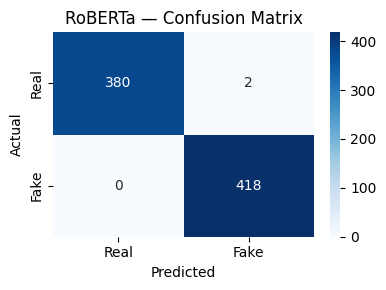

np.float64(0.9988570605476089)

In [40]:
rob_preds_raw = rob_trainer.predict(rob_test_ds)
rob_logits    = rob_preds_raw.predictions
rob_prob      = F.softmax(torch.tensor(rob_logits), dim=1).numpy()[:, 1]
rob_pred      = np.argmax(rob_logits, axis=1)
rob_true      = np.array(rob_test_labels)

evaluate('RoBERTa', rob_true, rob_pred, rob_prob, 'Fine-tuned')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding train texts...


Batches:   0%|          | 0/79 [00:00<?, ?it/s]

Encoding test texts...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Sentence embedding shape: (5000, 384)

  Sentence Transformer + LR (MiniLM-L6)
  Accuracy : 0.9330
  ROC-AUC  : 0.9834
              precision    recall  f1-score   support

        Real       0.93      0.93      0.93       473
        Fake       0.93      0.94      0.94       527

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



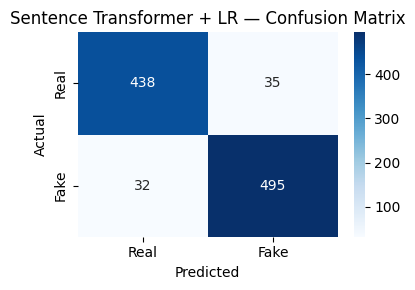

np.float64(0.9833835464213647)

In [41]:
ST_TRAIN = 5000
ST_TEST  = 1000

idx_st_tr = np.random.choice(len(X_train_txt), ST_TRAIN, replace=False)
idx_st_te = np.random.choice(len(X_test_txt),  ST_TEST,  replace=False)

st_train_texts  = X_train_txt[idx_st_tr].tolist()
st_train_labels = y_train[idx_st_tr]
st_test_texts   = X_test_txt[idx_st_te].tolist()
st_test_labels  = y_test[idx_st_te]

# Load Sentence Transformer
st_model = SentenceTransformer('all-MiniLM-L6-v2')

print("Encoding train texts...")
st_train_emb = st_model.encode(st_train_texts,
                                batch_size=64,
                                show_progress_bar=True)

print("Encoding test texts...")
st_test_emb  = st_model.encode(st_test_texts,
                                batch_size=64,
                                show_progress_bar=True)

print(f"Sentence embedding shape: {st_train_emb.shape}")

# Classify with Logistic Regression on top of ST embeddings
lr_st = LogisticRegression(max_iter=1000, random_state=42)
lr_st.fit(st_train_emb, st_train_labels)

st_pred = lr_st.predict(st_test_emb)
st_prob = lr_st.predict_proba(st_test_emb)[:, 1]

evaluate('Sentence Transformer + LR', st_test_labels,
         st_pred, st_prob, 'MiniLM-L6')

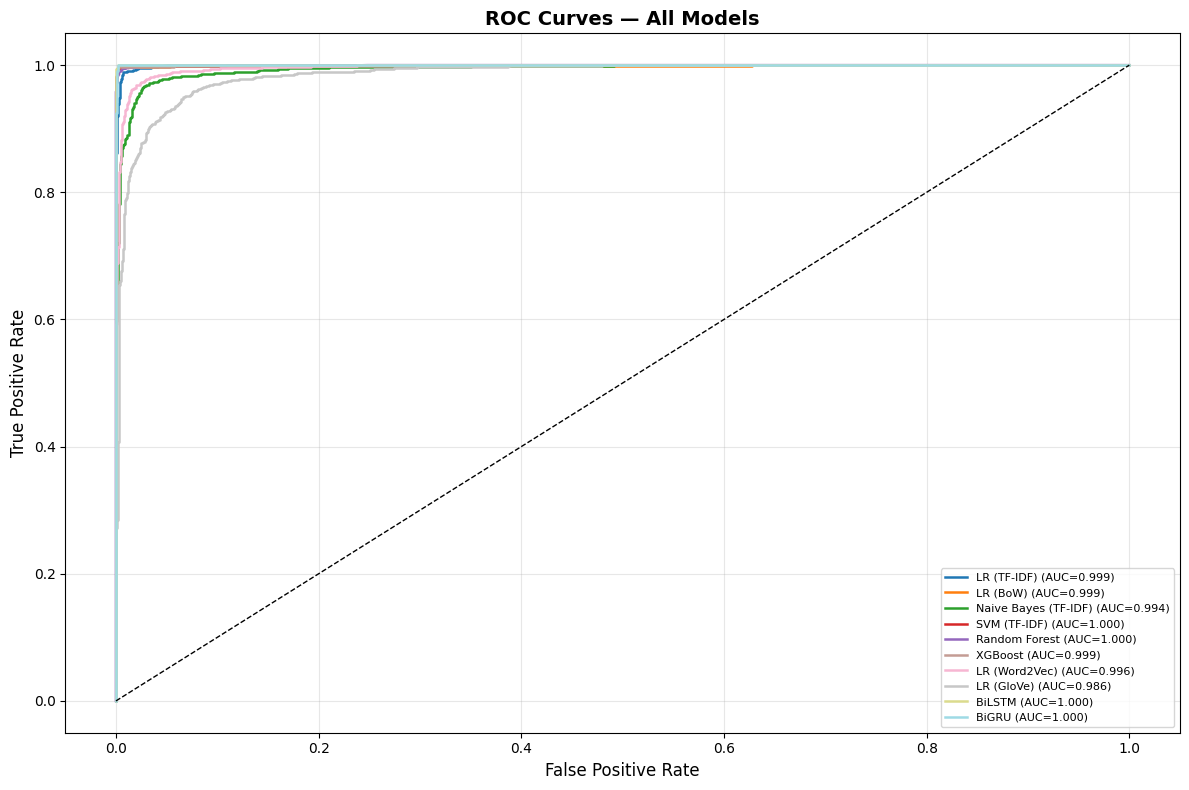

In [42]:
roc_data = {
    'LR (TF-IDF)'           : (y_test, lr_prob),
    'LR (BoW)'              : (y_test, lr_prob2),
    'Naive Bayes (TF-IDF)'  : (y_test, nb_prob),
    'SVM (TF-IDF)'          : (y_test, svm_score),
    'Random Forest'         : (y_test, rf_prob),
    'XGBoost'               : (y_test, xgb_prob),
    'LR (Word2Vec)'         : (y_test, w2v_prob),
    'LR (GloVe)'            : (y_test, glv_prob),
    'BiLSTM'                : (y_test, lstm_prob),
    'BiGRU'                 : (y_test, gru_prob),
}

plt.figure(figsize=(12, 8))
colors = plt.cm.tab20(np.linspace(0, 1, len(roc_data)))

for (name, (yt, yp)), color in zip(roc_data.items(), colors):
    fpr, tpr, _ = roc_curve(yt, yp)
    auc = roc_auc_score(yt, yp)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})',
             color=color, lw=1.8)

plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


 Full Performance Comparison:
                                       Accuracy   ROC-AUC
BERT (Fine-tuned)                       0.99875  1.000000
BiLSTM (GloVe Emb)                      0.99875  0.999987
BiGRU (GloVe Emb)                       0.99875  0.999912
Random Forest (TF-IDF)                  0.99325  0.999651
SVM (LinearSVC) (TF-IDF)                0.99675  0.999598
XGBoost (TF-IDF)                        0.99675  0.999315
Logistic Regression (TF-IDF)            0.98925  0.999084
Logistic Regression (BoW)               0.99625  0.998879
RoBERTa (Fine-tuned)                    0.99750  0.998857
Logistic Regression (Word2Vec)          0.97350  0.996129
Naive Bayes (TF-IDF)                    0.96800  0.993775
Logistic Regression (GloVe)             0.93950  0.985845
Naive Bayes (BoW)                       0.97000  0.985840
Sentence Transformer + LR (MiniLM-L6)   0.93300  0.983384


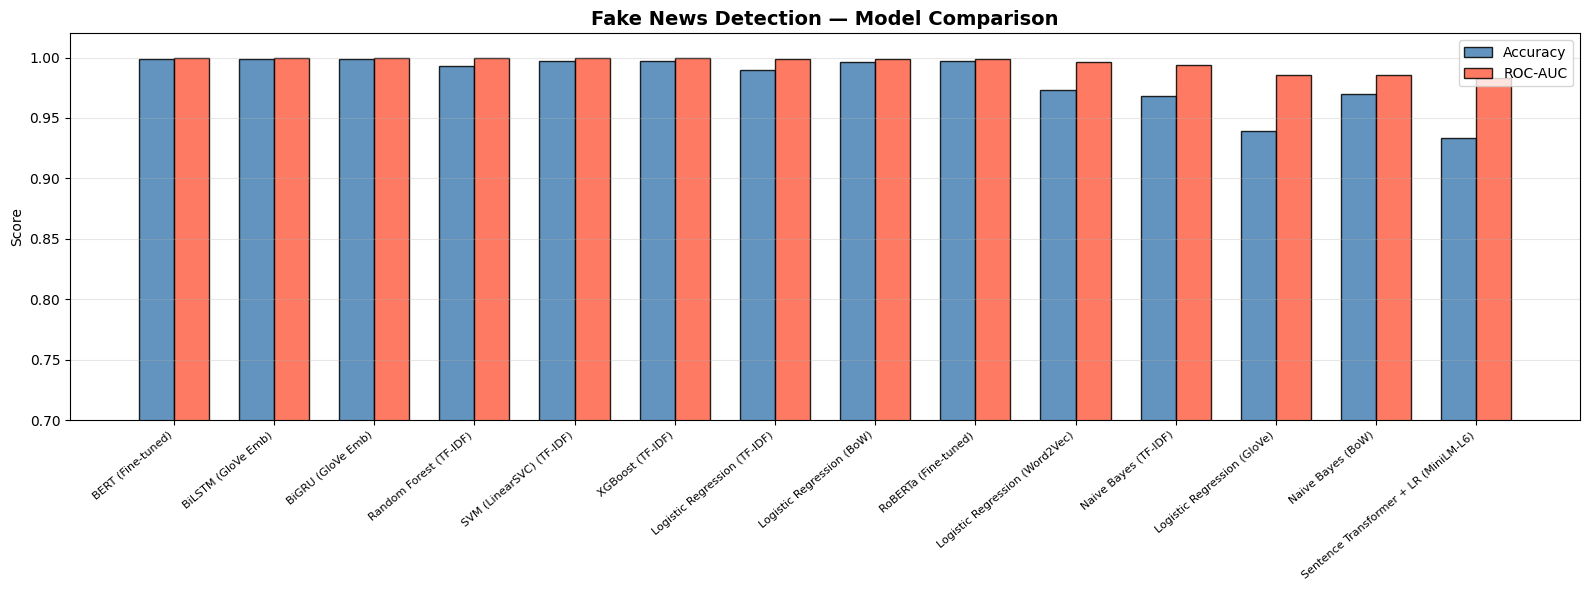

In [43]:
results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)

print("\n Full Performance Comparison:")
print("="*60)
print(results_df.to_string())

# Plot
fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(results_df))
w = 0.35

ax.bar(x - w/2, results_df['Accuracy'], width=w,
       label='Accuracy', color='steelblue', edgecolor='black', alpha=0.85)
ax.bar(x + w/2, results_df['ROC-AUC'],  width=w,
       label='ROC-AUC',  color='tomato',    edgecolor='black', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=40, ha='right', fontsize=8)
ax.set_ylim(0.70, 1.02)
ax.set_ylabel('Score')
ax.set_title('Fake News Detection — Model Comparison',
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

 5-Fold Cross-Validation (TF-IDF, ROC-AUC):
  Logistic Regression       0.9988 ± 0.0002
  Naive Bayes               0.9925 ± 0.0005
  Random Forest             0.9995 ± 0.0001


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:52:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:52:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:52:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:52:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

  XGBoost                   0.9997 ± 0.0002


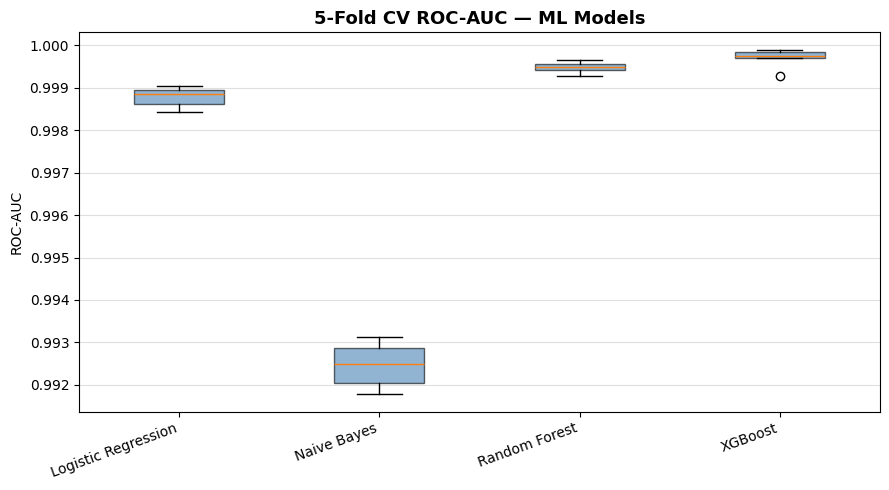

In [44]:
cv_models = {
    'Logistic Regression' : lr_tfidf,
    'Naive Bayes'         : nb_tfidf,
    'Random Forest'       : rf_tfidf,
    'XGBoost'             : xgb,
}

print(" 5-Fold Cross-Validation (TF-IDF, ROC-AUC):")

cv_scores = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, X_train_tfidf, y_train,
                             cv=5, scoring='roc_auc', n_jobs=-1)
    cv_scores[name] = scores
    print(f"  {name:<25} {scores.mean():.4f} ± {scores.std():.4f}")

# Box plot
plt.figure(figsize=(9, 5))
plt.boxplot(cv_scores.values(), labels=cv_scores.keys(),
            patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6))
plt.xticks(rotation=20, ha='right')
plt.ylabel('ROC-AUC')
plt.title('5-Fold CV ROC-AUC — ML Models', fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()

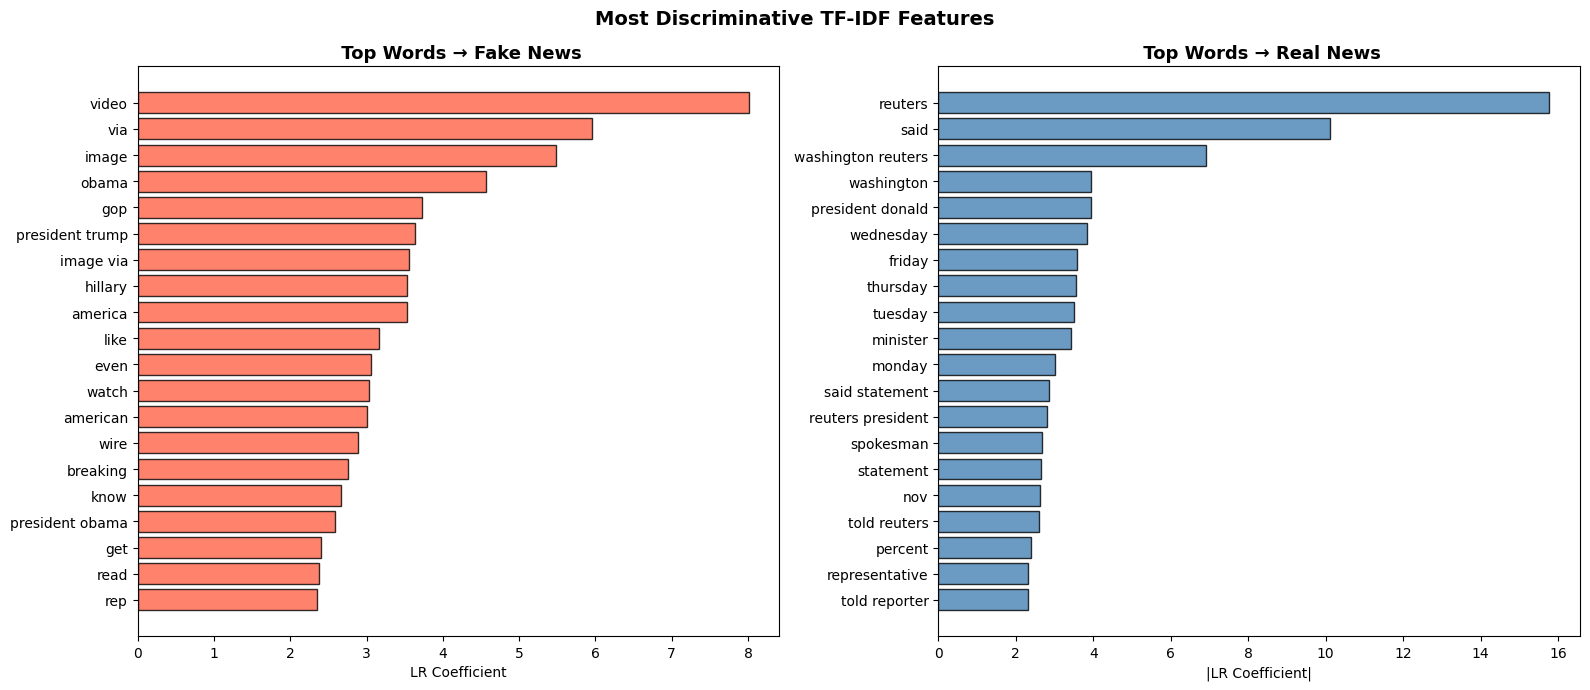

In [45]:
coef = lr_tfidf.coef_[0]
top_n = 20

top_fake_idx = coef.argsort()[-top_n:][::-1]
top_real_idx = coef.argsort()[:top_n]

top_fake_words = [(feature_names_tfidf[i], coef[i]) for i in top_fake_idx]
top_real_words = [(feature_names_tfidf[i], coef[i]) for i in top_real_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Fake words
words_f, vals_f = zip(*top_fake_words)
axes[0].barh(words_f, vals_f, color='tomato', edgecolor='black', alpha=0.8)
axes[0].set_title(' Top Words → Fake News', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].set_xlabel('LR Coefficient')

# Real words
words_r, vals_r = zip(*top_real_words)
axes[1].barh(words_r, [abs(v) for v in vals_r],
             color='steelblue', edgecolor='black', alpha=0.8)
axes[1].set_title(' Top Words → Real News', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
axes[1].set_xlabel('|LR Coefficient|')

plt.suptitle('Most Discriminative TF-IDF Features',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [46]:
def predict_news(text, tfidf_vec, lr_model, lstm_mdl, gru_mdl,
                 keras_tok_, max_len_=300):
    """Predict if a news article is Fake or Real."""
    cleaned = clean_text(text)

    # TF-IDF + LR
    tfidf_feat = tfidf_vec.transform([cleaned])
    lr_p       = lr_model.predict_proba(tfidf_feat)[0, 1]

    # LSTM
    seq     = keras_tok_.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=max_len_, padding='post')
    lstm_p  = lstm_mdl.predict(padded, verbose=0)[0][0]
    gru_p   = gru_mdl.predict(padded, verbose=0)[0][0]

    # Ensemble avg
    avg_p = (lr_p + lstm_p + gru_p) / 3

    label = ' FAKE' if avg_p > 0.5 else ' REAL'
    conf  = avg_p if avg_p > 0.5 else 1 - avg_p

    print(f"Article (first 150 chars): {text[:150]}...")
    print(f"\nLR Prob     (Fake): {lr_p:.4f}")
    print(f"LSTM Prob   (Fake): {lstm_p:.4f}")
    print(f"GRU Prob    (Fake): {gru_p:.4f}")
    print(f"Ensemble    (Fake): {avg_p:.4f}")
    print(f"\nPrediction : {label}  (Confidence: {conf*100:.1f}%)")
    return avg_p

# Test with a fake article
fake_article = """
Breaking: Scientists confirm that drinking bleach cures all diseases.
The government is hiding this truth from the public. 
Share this before they delete it! The mainstream media won't report this!
"""

print("\n--- Test Article 1 (Likely Fake) ---")
predict_news(fake_article, tfidf, lr_tfidf, lstm_model, gru_model, keras_tok)

# Test with a real article
real_article = """
The Federal Reserve announced on Wednesday that it would keep interest
rates unchanged at its latest policy meeting. Fed Chair stated that
inflation is gradually returning to the 2% target and the economy
remains resilient with strong labor market conditions.
"""
print("\n--- Test Article 2 (Likely Real) ---")
predict_news(real_article, tfidf, lr_tfidf, lstm_model, gru_model, keras_tok)


--- Test Article 1 (Likely Fake) ---
Article (first 150 chars): 
Breaking: Scientists confirm that drinking bleach cures all diseases.
The government is hiding this truth from the public. 
Share this before they de...

LR Prob     (Fake): 0.8845
LSTM Prob   (Fake): 0.9991
GRU Prob    (Fake): 0.9995
Ensemble    (Fake): 0.9611

Prediction :  FAKE  (Confidence: 96.1%)

--- Test Article 2 (Likely Real) ---
Article (first 150 chars): 
The Federal Reserve announced on Wednesday that it would keep interest
rates unchanged at its latest policy meeting. Fed Chair stated that
inflation ...

LR Prob     (Fake): 0.4281
LSTM Prob   (Fake): 0.9954
GRU Prob    (Fake): 0.9877
Ensemble    (Fake): 0.8038

Prediction :  FAKE  (Confidence: 80.4%)


np.float64(0.8037686244487189)

In [47]:
final_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
final_df['Accuracy']  = final_df['Accuracy'].apply(lambda x: f"{x:.4f}")
final_df['ROC-AUC']   = final_df['ROC-AUC'].apply(lambda x: f"{x:.4f}")
print(final_df.to_string())

print("\n" + "-"*65)
res_num = pd.DataFrame(results).T
print(f"  🥇 Best ROC-AUC  : {res_num['ROC-AUC'].idxmax()}  "
      f"({res_num['ROC-AUC'].max():.4f})")
print(f"  🥇 Best Accuracy : {res_num['Accuracy'].idxmax()}  "
      f"({res_num['Accuracy'].max():.4f})")

                                      Accuracy ROC-AUC
BERT (Fine-tuned)                       0.9988  1.0000
BiLSTM (GloVe Emb)                      0.9988  1.0000
BiGRU (GloVe Emb)                       0.9988  0.9999
Random Forest (TF-IDF)                  0.9932  0.9997
SVM (LinearSVC) (TF-IDF)                0.9968  0.9996
XGBoost (TF-IDF)                        0.9968  0.9993
Logistic Regression (TF-IDF)            0.9892  0.9991
Logistic Regression (BoW)               0.9962  0.9989
RoBERTa (Fine-tuned)                    0.9975  0.9989
Logistic Regression (Word2Vec)          0.9735  0.9961
Naive Bayes (TF-IDF)                    0.9680  0.9938
Logistic Regression (GloVe)             0.9395  0.9858
Naive Bayes (BoW)                       0.9700  0.9858
Sentence Transformer + LR (MiniLM-L6)   0.9330  0.9834

-----------------------------------------------------------------
  🥇 Best ROC-AUC  : BERT (Fine-tuned)  (1.0000)
  🥇 Best Accuracy : BiLSTM (GloVe Emb)  (0.9988)
